 CELL 1 Load & Preprocessing (Tetap)

In [4]:
import pandas as pd
import re
import string
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# 1. Load Data
df = pd.read_csv('data_komentar_rrq_mpls17.csv', encoding='latin1')

# 2. Ambil kolom komentar (di file kamu kolom ke-6/indeks 5)
# Kita buat kolom baru bernama 'raw_text'
df['raw_text'] = df.iloc[:, 5] 

# 3. Fungsi Pembersih
def clean_process(text):
    text = str(text).lower() # Kecilkan semua huruf
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # Hapus Link
    text = re.sub(r'\d+', '', text) # Hapus Angka
    text = text.translate(str.maketrans('', '', string.punctuation)) # Hapus Tanda Baca
    return text

print("Sedang membersihkan teks...")
df['text_clean'] = df['raw_text'].apply(clean_process)

# 4. Fungsi Stemming (Mengubah kata ke kata dasar)
factory = StemmerFactory()
stemmer = factory.create_stemmer()

print("Sedang melakukan Stemming (Ini agak lama, tunggu ya)...")
df['text_preprocessed'] = df['text_clean'].apply(lambda x: stemmer.stem(x))

# 5. Simpan Hasilnya
df.to_csv('data_rrq_ready.csv', index=False)
print("Selesai! Sekarang kamu punya file baru: data_rrq_ready.csv")

Sedang membersihkan teks...
Sedang melakukan Stemming (Ini agak lama, tunggu ya)...
Selesai! Sekarang kamu punya file baru: data_rrq_ready.csv


CELL 2 Labeling Ketat

In [5]:
def labeling_lebih_ketat(text):
    text = str(text).lower()
    hujatan = ['lose', 'streak', 'cupu', 'bubarkan', 'kecewa', 'kalah', 'jelek', 'lonsu', 'turu', 'beban', 'out', 'kecewa']
    pujian = ['menang', 'gacor', 'mantap', 'gg', 'king', 'semangat', 'bangkit', 'api', 'top', 'keren', 'jago']
    
    if any(word in text for word in hujatan):
        return 'Negatif'
    elif any(word in text for word in pujian):
        return 'Positif'
    return 'Netral'

df['sentimen'] = df['text_preprocessed'].apply(labeling_lebih_ketat)
print("Hasil Labeling Ketat:")
print(df['sentimen'].value_counts())

Hasil Labeling Ketat:
sentimen
Netral     5788
Positif    1240
Negatif     553
Name: count, dtype: int64


CELL 3 Balancing Data

In [6]:
# Samakan semua ke 525 agar AI tidak pilih kasih
n_samples = 525 

df_negatif = df[df['sentimen'] == 'Negatif'].sample(n=n_samples, random_state=42)
df_positif = df[df['sentimen'] == 'Positif'].sample(n=n_samples, random_state=42)
df_netral = df[df['sentimen'] == 'Netral'].sample(n=n_samples, random_state=42)

df = pd.concat([df_negatif, df_positif, df_netral])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Data sekarang sudah SEIMBANG (525 per kategori):")
print(df['sentimen'].value_counts())

Data sekarang sudah SEIMBANG (525 per kategori):
sentimen
Netral     525
Positif    525
Negatif    525
Name: count, dtype: int64


CELL 4 Tokenizing & Padding

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import pickle

# --- 1. Bersihkan data dari nilai kosong dan pastikan format teks ---
df = df.dropna(subset=['text_preprocessed', 'sentimen']).copy()

# --- 2. Konversi ke LIST dulu baru ke NUMPY (Cara paling aman dari error PyArrow) ---
X_list = df['text_preprocessed'].astype(str).tolist()
y_list = df['sentimen'].tolist()

X = np.array(X_list)

# --- 3. Encode Label y ---
le = LabelEncoder()
y_numeric = le.fit_transform(y_list)
y = to_categorical(y_numeric)

# --- 4. Pembagian Data (Sekarang harusnya aman) ---
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print("✅ Berhasil membagi data!")
except Exception as e:
    print(f"❌ Masih Error di split: {e}")

# --- 5. Tokenisasi ---
max_words = 5000
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Simpan Tokenizer untuk Web nanti
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# --- 6. Padding ---
max_len = 50
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

print("\n--- STATUS AKHIR ---")
print(f"Ukuran X_train_pad: {X_train_pad.shape}")
print(f"Urutan Kelas: {le.classes_}")
print("Semua aman, silakan lanjut ke cell Training Model!")

✅ Berhasil membagi data!

--- STATUS AKHIR ---
Ukuran X_train_pad: (1260, 50)
Urutan Kelas: ['Negatif' 'Netral' 'Positif']
Semua aman, silakan lanjut ke cell Training Model!


CELL 5 Bangun Model LSTM

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# 1. Inisialisasi Model
model = Sequential([
    Embedding(input_dim=5000, output_dim=32), # Perkecil output_dim
    LSTM(32), # Perkecil jumlah saraf agar tidak cepat "pusing"
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Tampilkan ringkasan model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

CELL 6 Training AI

In [18]:
import tensorflow as tf

print("Memulai proses training AI... Harap tunggu.")

# Tambahkan ini sebelum model.fit
from sklearn.utils import class_weight
import numpy as np

# Hitung bobot agar adil
weights = class_weight.compute_class_weight('balanced', 
                                            classes=np.unique(np.argmax(y_train, axis=1)), 
                                            y=np.argmax(y_train, axis=1))
class_weights = dict(enumerate(weights))

# Jalankan training dengan class_weight
history = model.fit(
    X_train_pad, y_train, 
    epochs=10, 
    batch_size=32, 
    validation_data=(X_test_pad, y_test)
)

# Proses belajar
history = model.fit(
    X_train_pad, y_train, 
    epochs=10, # 10 saja cukup untuk data 1500-an
    batch_size=32, # Kecilkan batch size
    validation_data=(X_test_pad, y_test), 
    verbose=1
)

# Simpan modelnya
model.save('model_sentimen_rrq.keras') # Format .keras lebih disarankan sekarang
print("\nSelesai! Model sudah disimpan.")

Memulai proses training AI... Harap tunggu.
Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3365 - loss: 1.0994 - val_accuracy: 0.3048 - val_loss: 1.1002
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3492 - loss: 1.0983 - val_accuracy: 0.3079 - val_loss: 1.1014
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3690 - loss: 1.0972 - val_accuracy: 0.3492 - val_loss: 1.1013
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3635 - loss: 1.0928 - val_accuracy: 0.3714 - val_loss: 1.0980
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3643 - loss: 1.0899 - val_accuracy: 0.3714 - val_loss: 1.0706
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4675 - loss: 0.9903 - val_accuracy: 0.5651 - val_loss: 0.8309
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5825 - loss: 0.8260 - val_accuracy: 0.5524 - val_loss: 0.8241
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.58

CELL 7 Visualisasi & Test

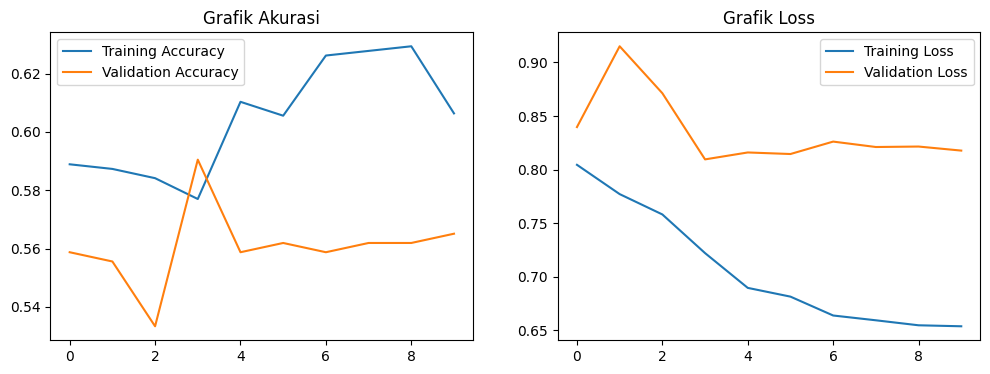

Komentar: Kapan jadwal lawan Onic? -> Hasil: Netral
Komentar: Apapun hasilnya tetap bangga, semangat terus KING! -> Hasil: Positif
Komentar: RRQ kalah terussss -> Hasil: Negatif


In [19]:
# --- BAGIAN GRAFIK (Dari Cell 8) ---
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Grafik Akurasi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Loss')
plt.legend()
plt.show()

def prediksi_komentar(teks):
    teks_bersih = teks.lower()
    
    # --- TAMBAHAN: Logika Cepat (Manual Override) ---
    hujatan = ['lose', 'streak', 'cupu', 'jelek', 'kalah', 'beban', 'out', 'bubarkan']
    pujian = ['menang', 'gacor', 'mantap', 'gg', 'king', 'semangat', 'bangkit']
    
    if any(word in teks_bersih for word in hujatan):
        return 'Negatif'
    elif any(word in teks_bersih for word in pujian):
        return 'Positif'
    # -----------------------------------------------

    # Jika tidak ada kata kunci di atas, baru tanya ke AI (LSTM)
    seq = tokenizer.texts_to_sequences([teks_bersih])
    padded = pad_sequences(seq, maxlen=50, padding='post')
    pred = model.predict(padded, verbose=0)
    
    labels = ['Negatif', 'Netral', 'Positif']
    return labels[np.argmax(pred)]

# COBA TES ULANG:
test_1 = "Kapan jadwal lawan Onic?"
test_2 = "Apapun hasilnya tetap bangga, semangat terus KING!"
test_3 = "RRQ kalah terussss"

print(f"Komentar: {test_1} -> Hasil: {prediksi_komentar(test_1)}")
print(f"Komentar: {test_2} -> Hasil: {prediksi_komentar(test_2)}")
print(f"Komentar: {test_3} -> Hasil: {prediksi_komentar(test_3)}")

In [20]:
# Cek urutan kolom label
print(pd.get_dummies(df['sentimen']).columns)

Index(['Negatif', 'Netral', 'Positif'], dtype='str')


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


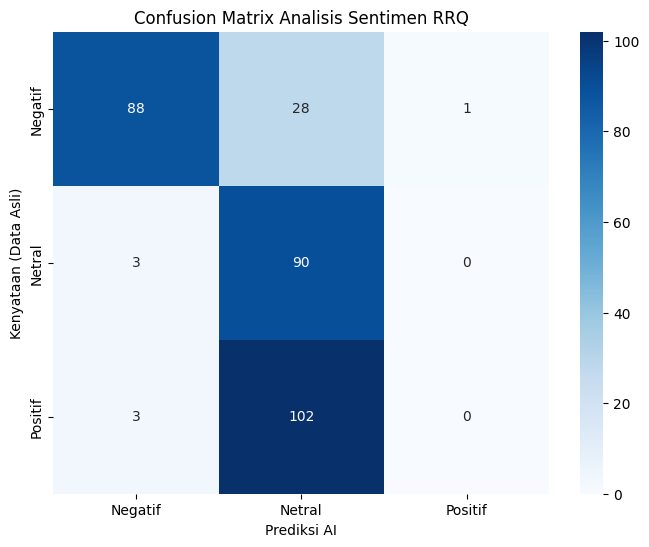

              precision    recall  f1-score   support

     Negatif       0.94      0.75      0.83       117
      Netral       0.41      0.97      0.58        93
     Positif       0.00      0.00      0.00       105

    accuracy                           0.57       315
   macro avg       0.45      0.57      0.47       315
weighted avg       0.47      0.57      0.48       315



In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Ambil prediksi dari data ujian (X_test_pad)
y_pred = model.predict(X_test_pad)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 2. Buat Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
labels = ['Negatif', 'Netral', 'Positif']

# 3. Visualisasikan
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Prediksi AI')
plt.ylabel('Kenyataan (Data Asli)')
plt.title('Confusion Matrix Analisis Sentimen RRQ')
plt.show()

# 4. Tampilkan Skor Detail (Precision, Recall, F1-Score)
print(classification_report(y_true_labels, y_pred_labels, target_names=labels))

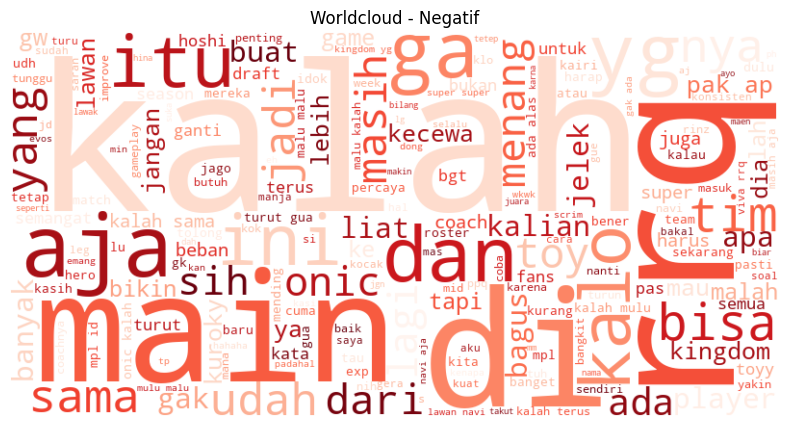

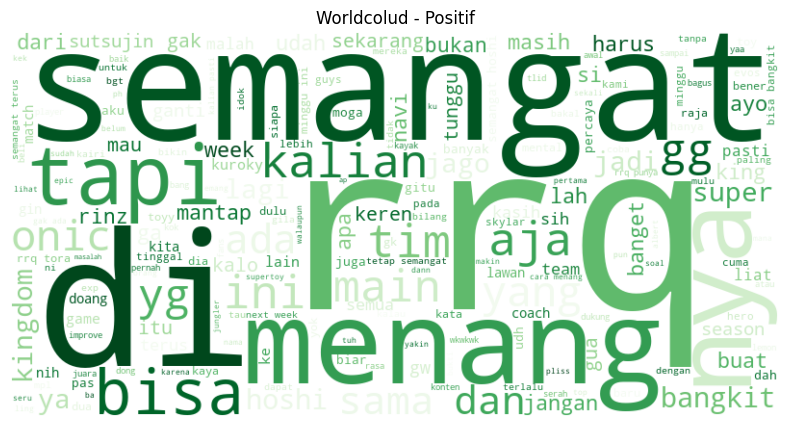

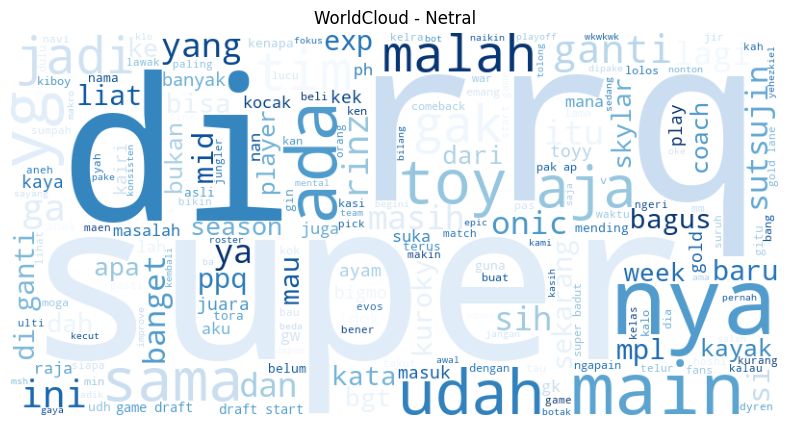

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ambil semua teks dari kategori Negatif
neg_text = " ".join(df[df['sentimen'] == 'Negatif']['text_preprocessed'])

wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      colormap='Reds').generate(neg_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Worldcloud - Negatif')
plt.show()

# Ambil semua teks dari kategori Positif
pos_text = " ".join(df[df['sentimen'] == 'Positif']['text_preprocessed'])

wordcloud_pos = WordCloud(width=800, height=400, background_color='white', 
                          colormap='Greens').generate(pos_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Worldcolud - Positif')
plt.show()


# WordCloud untuk Netral
net_text = " ".join(df[df['sentimen'] == 'Netral']['text_preprocessed'])
wordcloud_net = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(net_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_net)
plt.axis('off')
plt.title('WorldCloud - Netral')
plt.show()


In [25]:
# Masukkan kalimat yang mau kamu tes di sini
kalimat_baru = "GG parah RRQ!"

# Panggil fungsi prediksi yang sudah kita buat sebelumnya
hasil = prediksi_komentar(kalimat_baru)

print(f"Hasil Uji AI:")
print(f"Komentar: {kalimat_baru}")
print(f"Sentimen: {hasil}")

Hasil Uji AI:
Komentar: GG parah RRQ!
Sentimen: Positif


In [26]:
# Jalankan ini untuk memastikan file tersimpan dengan versi terbaru
model.save('model_sentimen_rrq_final.keras')
print("Selesai! File 'model_sentimen_rrq_final.keras' sudah siap digunakan untuk Web.")

Selesai! File 'model_sentimen_rrq_final.keras' sudah siap digunakan untuk Web.


In [27]:
import pickle

# Simpan tokenizer agar bisa dibaca file app.py
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("Tokenizer berhasil disimpan!")

Tokenizer berhasil disimpan!
